# 02 – Análise exploratória da criminalidade no Paraná (2018–2024)

Neste notebook é realizada a análise exploratória da base `base_criminalidade_pr_limpa.csv`,
derivada dos dados de criminalidade do IPARDES para o estado do Paraná entre 2018 e 2024.
O foco é identificar padrões temporais e espaciais, diferenças entre grupos de crime
e, de forma mais aprofundada, analisar as **mortes violentas intencionais** e os
**crimes de estelionato no período pós-2020**.


## 1. Imports e carregamento da base

In [50]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo básico pros gráficos
plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.0)

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"

# Carrega a base limpa
df = pd.read_csv(PROCESSED_DIR / "base_criminalidade_pr_limpa.csv")

# Ajustes básicos
df["quantidade"] = df["quantidade"].astype("int64")
df["ano"] = df["ano"].astype("int64")

df.head()


,municipio,regiao,ano,tipo_crime,quantidade,fonte
0,Estado do Paraná,-,2018,Armas de Fogo Apreendidas,6267,Crimes gerais
1,Estado do Paraná,-,2019,Armas de Fogo Apreendidas,6150,Crimes gerais
2,Estado do Paraná,-,2020,Armas de Fogo Apreendidas,7129,Crimes gerais
3,Estado do Paraná,-,2021,Armas de Fogo Apreendidas,6666,Crimes gerais
4,Estado do Paraná,-,2022,Armas de Fogo Apreendidas,6216,Crimes gerais


## 2. Visão geral da base

Primeiro, verificamos o formato geral da base de dados, anos cobertos,
tipos de crime disponíveis e fontes de informação.


In [51]:
print("Formato:", df.shape)
print("\nColunas:")
print(df.columns.tolist())

print("\nAnos disponíveis:")
print(df["ano"].value_counts().sort_index())

print("\nTipos de crime:")
print(df["tipo_crime"].value_counts())

print("\nFontes:")
print(df["fonte"].value_counts())


Formato: (34037, 6)

Colunas:
['municipio', 'regiao', 'ano', 'tipo_crime', 'quantidade', 'fonte']

Anos disponíveis:
ano
2018    4932
2019    4921
2020    4860
2021    4832
2022    4840
2023    4852
2024    4800
Name: count, dtype: int64

Tipos de crime:
tipo_crime
Crimes de Ameaça                                        2800
Crimes de Lesão Corporal                                2800
Crimes de Furto                                         2800
Crimes de Estelionato                                   2789
Perturbação do Sossego/Tranquilidade                    2764
Crimes de Estupro                                       2657
Armas de Fogo Apreendidas                               2604
Crimes de Roubo                                         2573
Furtos de Veículos                                      2565
Ocorrências Envolvendo Uso/Consumo de Drogas            2495
Ocorrências Envolvendo Tráfico de Drogas                2449
Roubos de Veículos                                      1916
Ví

## 3. Criação da variável `grupo_crime`

Para facilitar a análise, agrupamos os tipos de crime em categorias mais amplas,
como crimes contra o patrimônio, crimes contra a pessoa, drogas e mortes violentas
intencionais. Esta etapa é uma forma simples de engenharia de atributos.


In [52]:
def classificar_grupo(tipo):
    if tipo in [
        "Crimes de Furto",
        "Crimes de Roubo",
        "Furtos de Veículos",
        "Roubos de Veículos",
        "Crimes de Estelionato",
    ]:
        return "Crimes contra o patrimônio"
    elif tipo in [
        "Crimes de Ameaça",
        "Crimes de Lesão Corporal",
        "Crimes de Estupro",
        "Perturbação do Sossego/Tranquilidade",
    ]:
        return "Crimes contra a pessoa (não letais)"
    elif tipo in [
        "Ocorrências Envolvendo Tráfico de Drogas",
        "Ocorrências Envolvendo Uso/Consumo de Drogas",
    ]:
        return "Drogas"
    elif tipo in [
        "Vítimas de Feminicídio",
        "Vítimas de Homicídio Doloso",
        "Vítimas de Homicídio Doloso no Trânsito",
        "Vítimas de Lesão Corporal com Resultado de Morte",
        "Vítimas de Roubo com Resultado de Morte (Latrocínio)",
    ]:
        return "Mortes violentas intencionais"
    elif tipo == "Armas de Fogo Apreendidas":
        return "Armas de fogo apreendidas"
    else:
        return "Outros"

df["grupo_crime"] = df["tipo_crime"].map(classificar_grupo)

df["grupo_crime"].value_counts()


grupo_crime
Crimes contra o patrimônio             12643
Crimes contra a pessoa (não letais)    11021
Drogas                                  4944
Mortes violentas intencionais           2825
Armas de fogo apreendidas               2604
Name: count, dtype: int64

## 4. Separação entre linha agregada do estado e municípios

A base contém uma linha agregada para o "Estado do Paraná" e linhas individuais
para cada município. Para evitar dupla contagem, separamos essas duas visões.


In [53]:
estado = df.query("municipio == 'Estado do Paraná'").copy()
municipios = df.query("municipio != 'Estado do Paraná'").copy()

estado.shape, municipios.shape


((119, 7), (33918, 7))

## 5. Total de ocorrências por ano (Estado do Paraná)

Aqui analisamos a evolução do total de registros de criminalidade no estado
entre 2018 e 2024.


In [54]:
tot_ano_estado = (
    estado.groupby("ano")["quantidade"]
    .sum()
    .reset_index()
    .sort_values("ano")
)

tot_ano_estado


,ano,quantidade
0,2018,535047
1,2019,525214
2,2020,492477
3,2021,544375
4,2022,587626
5,2023,616806
6,2024,613797


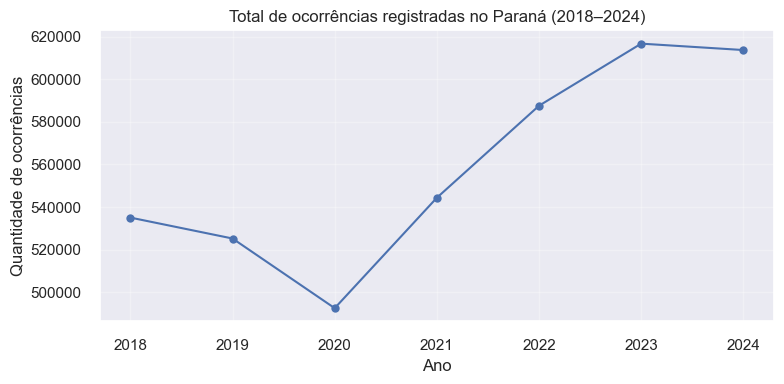

In [55]:
plt.figure(figsize=(8, 4))
plt.plot(tot_ano_estado["ano"], tot_ano_estado["quantidade"], marker="o")
plt.title("Total de ocorrências registradas no Paraná (2018–2024)")
plt.xlabel("Ano")
plt.ylabel("Quantidade de ocorrências")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretação:** observa-se uma queda do total de ocorrências em 2020,
seguida de um forte aumento em 2021 e 2022. Ainda que haja uma leve redução
em 2023 e 2024, o patamar recente permanece acima dos níveis observados em 2018–2019.
Esse comportamento é compatível com o período de pandemia (redução em 2020)
e retomada das atividades nos anos seguintes.


## 6. Distribuição por grupos de crime (Estado do Paraná)

Nesta seção analisamos a evolução dos principais grupos de crime ao longo dos anos
para o estado do Paraná como um todo. O objetivo é entender quais grupos ajudam
a explicar o comportamento do total de ocorrências.


In [56]:
grupo_ano_estado = (
    estado.groupby(["ano", "grupo_crime"])["quantidade"]
    .sum()
    .reset_index()
)

pivot_grupo_ano = grupo_ano_estado.pivot(
    index="ano", columns="grupo_crime", values="quantidade"
)

pivot_grupo_ano


grupo_crime,Armas de fogo apreendidas,Crimes contra a pessoa (não letais),Crimes contra o patrimônio,Drogas,Mortes violentas intencionais
ano,,,,,
2018,6267,211019,287548,28041,2172
2019,6150,222179,267365,27477,2043
2020,7129,195446,261052,26646,2204
2021,6666,194497,317274,23833,2105
2022,6216,197223,362977,19002,2208
2023,6317,230434,352376,25642,2037
2024,5686,238720,339920,27690,1781


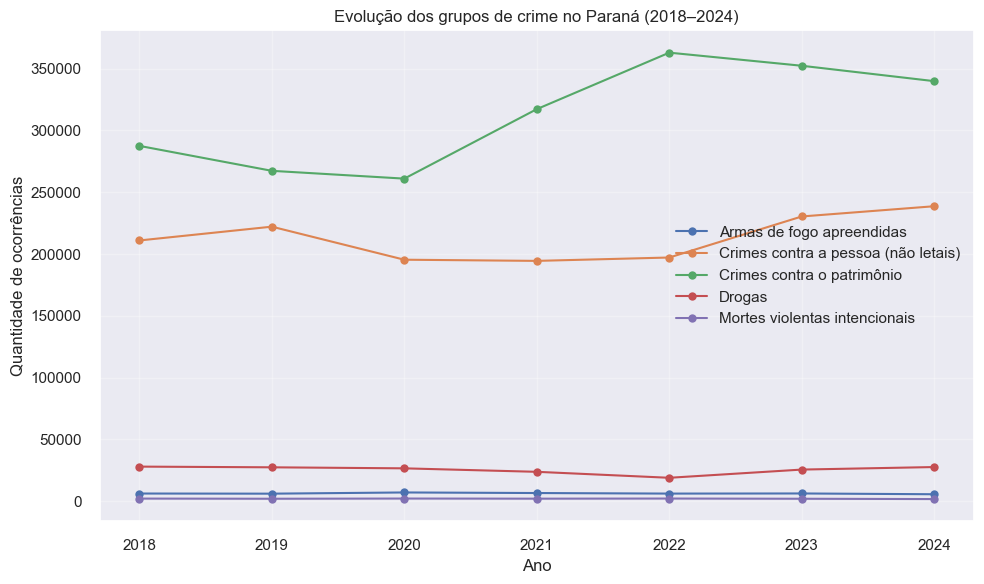

In [57]:
plt.figure(figsize=(10, 6))
for col in pivot_grupo_ano.columns:
    plt.plot(pivot_grupo_ano.index, pivot_grupo_ano[col], marker="o", label=col)

plt.title("Evolução dos grupos de crime no Paraná (2018–2024)")
plt.xlabel("Ano")
plt.ylabel("Quantidade de ocorrências")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretação:** os crimes contra o patrimônio concentram o maior volume de
ocorrências ao longo de todo o período, seguidos pelos crimes contra a pessoa
(não letais). Há uma queda geral até 2020 e um aumento expressivo a partir de
2021, em especial nos crimes patrimoniais. As mortes violentas intencionais
permanecem em patamar numérico bem inferior, embora sejam crimes de maior gravidade.


## 7. Participação percentual dos grupos de crime

Além dos valores absolutos, é útil observar qual a participação relativa de
cada grupo de crime no total de ocorrências de cada ano.


In [58]:
tot_ano = (
    estado.groupby("ano")["quantidade"]
    .sum()
    .rename("total_ano")
    .reset_index()
)

grupo_ano_pct = grupo_ano_estado.merge(tot_ano, on="ano")
grupo_ano_pct["perc"] = grupo_ano_pct["quantidade"] / grupo_ano_pct["total_ano"] * 100

grupo_ano_pct.head()


,ano,grupo_crime,quantidade,total_ano,perc
0,2018,Armas de fogo apreendidas,6267,535047,1.171299
1,2018,Crimes contra a pessoa (não letais),211019,535047,39.439339
2,2018,Crimes contra o patrimônio,287548,535047,53.742568
3,2018,Drogas,28041,535047,5.240848
4,2018,Mortes violentas intencionais,2172,535047,0.405946


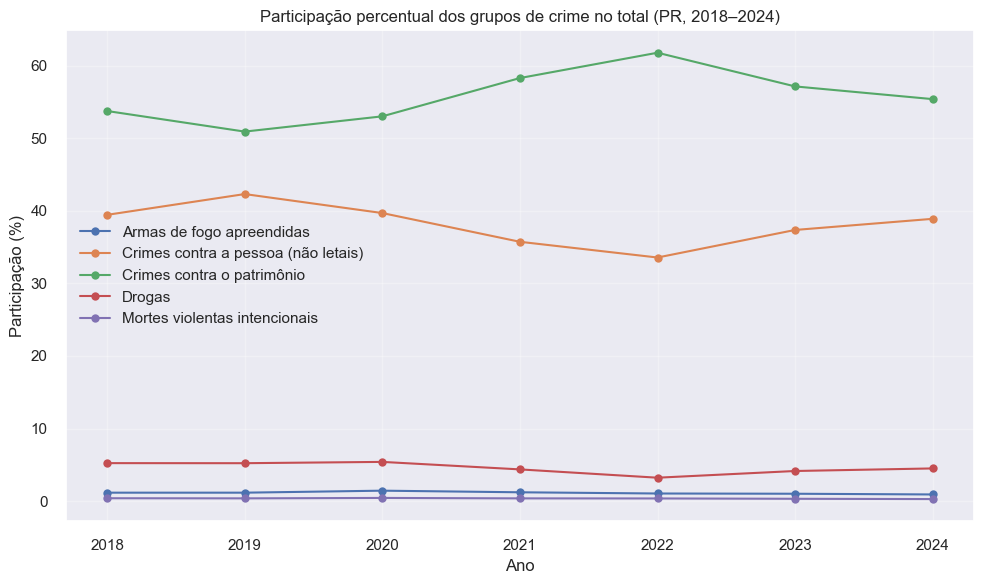

In [59]:
plt.figure(figsize=(10, 6))
for grupo in grupo_ano_pct["grupo_crime"].unique():
    dados = grupo_ano_pct[grupo_ano_pct["grupo_crime"] == grupo]
    plt.plot(dados["ano"], dados["perc"], marker="o", label=grupo)

plt.title("Participação percentual dos grupos de crime no total (PR, 2018–2024)")
plt.xlabel("Ano")
plt.ylabel("Participação (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretação:** os crimes contra o patrimônio representam uma parcela
expressiva do total de ocorrências em todos os anos, enquanto os crimes contra
a pessoa também mantêm participação relevante. As mortes violentas intencionais
correspondem a uma fração pequena do conjunto de registros, mesmo quando há
variações no número absoluto de casos.


## 8. Ranking de tipos de crime (2018–2024, Paraná)

Aqui somamos as ocorrências de todo o período para identificar quais tipos de
crime concentram o maior número de registros no estado.


In [60]:
tipo_tot_estado = (
    estado.groupby("tipo_crime")["quantidade"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

tipo_tot_estado


,tipo_crime,quantidade
0,Crimes de Furto,1116959
1,Crimes de Ameaça,743778
2,Crimes de Estelionato,709363
3,Crimes de Lesão Corporal,457562
4,Perturbação do Sossego/Tranquilidade,241443
5,Crimes de Roubo,236202
6,Furtos de Veículos,95166
7,Ocorrências Envolvendo Uso/Consumo de Drogas,91986
8,Ocorrências Envolvendo Tráfico de Drogas,86345
9,Crimes de Estupro,46735


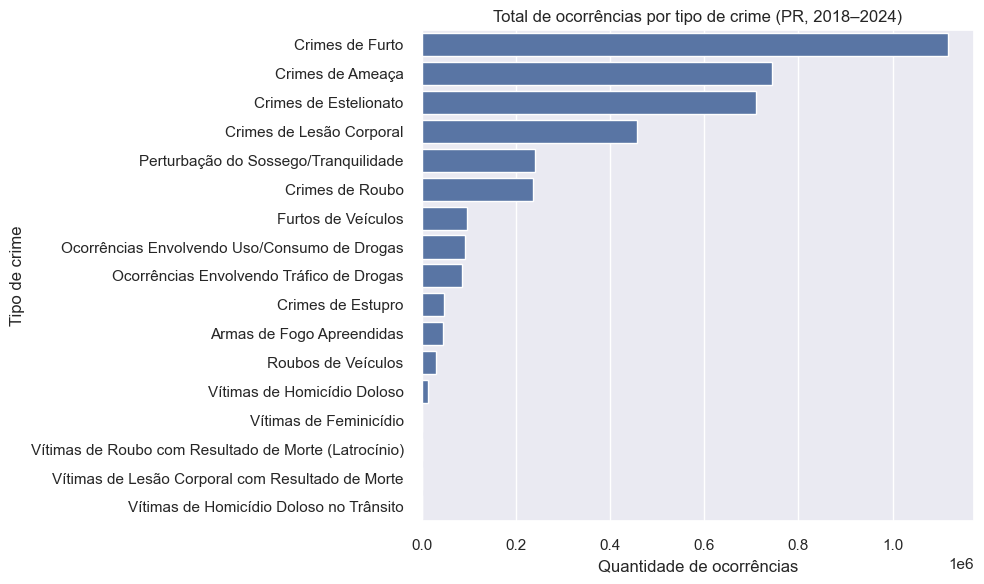

In [61]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=tipo_tot_estado,
    y="tipo_crime",
    x="quantidade",
    orient="h"
)
plt.title("Total de ocorrências por tipo de crime (PR, 2018–2024)")
plt.xlabel("Quantidade de ocorrências")
plt.ylabel("Tipo de crime")
plt.tight_layout()
plt.show()


**Interpretação:** o ranking evidencia o peso dos crimes contra o patrimônio e
de conflitos interpessoais no perfil da criminalidade paranaense. Destacam-se
os crimes de furto, de ameaça e de estelionato, além de lesão corporal e
perturbação do sossego. Já crimes letais, como homicídio doloso e latrocínio,
aparecem nas últimas posições em termos de volume absoluto, embora sejam
socialmente mais graves.


## 9. Mapa de calor: tipo de crime × ano

Para visualizar a distribuição dos tipos de crime ao longo do tempo de forma
mais compacta, utilizamos um mapa de calor relacionando tipo de crime e ano.


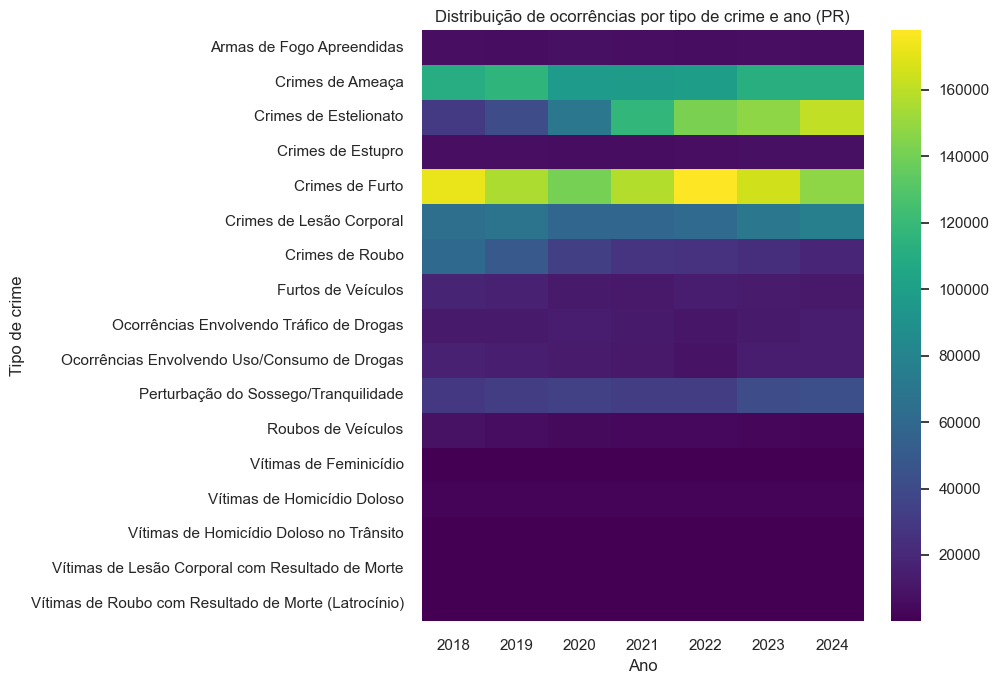

In [62]:
tabela_heat = (
    estado.groupby(["ano", "tipo_crime"])["quantidade"]
    .sum()
    .reset_index()
    .pivot(index="tipo_crime", columns="ano", values="quantidade")
)

plt.figure(figsize=(10, 7))
sns.heatmap(tabela_heat, annot=False, cmap="viridis")
plt.title("Distribuição de ocorrências por tipo de crime e ano (PR)")
plt.xlabel("Ano")
plt.ylabel("Tipo de crime")
plt.tight_layout()
plt.show()


**Interpretação:** o mapa de calor reforça a concentração de ocorrências em
crimes de furto, ameaça e estelionato, especialmente nos anos mais recentes.
Alguns tipos permanecem relativamente estáveis ao longo do tempo, enquanto outros
apresentam intensificação em períodos específicos, sugerindo mudanças no padrão
de ocorrência ou de registro.


## 10. Municípios com mais vítimas de homicídio doloso (2024)

Nesta seção, analisamos os municípios com maior número de vítimas de homicídio
doloso em 2024, considerando apenas os registros municipais.


In [63]:
homi_2024 = (
    municipios.query(
        "ano == 2024 and tipo_crime == 'Vítimas de Homicídio Doloso'"
    )
    .sort_values("quantidade", ascending=False)
    .head(10)
)

homi_2024


,municipio,regiao,ano,tipo_crime,quantidade,fonte,grupo_crime
31984,Curitiba,RGI de Curitiba,2024,Vítimas de Homicídio Doloso,167,Mortes violentas,Mortes violentas intencionais
33244,Ponta Grossa,RGI de Ponta Grossa,2024,Vítimas de Homicídio Doloso,88,Mortes violentas,Mortes violentas intencionais
33066,Paranaguá,RGI de Paranaguá,2024,Vítimas de Homicídio Doloso,65,Mortes violentas,Mortes violentas intencionais
31762,Cascavel,RGI de Cascavel,2024,Vítimas de Homicídio Doloso,61,Mortes violentas,Mortes violentas intencionais
32136,Foz do Iguaçu,RGI de Foz do Iguaçu,2024,Vítimas de Homicídio Doloso,60,Mortes violentas,Mortes violentas intencionais
32613,Londrina,RGI de Londrina,2024,Vítimas de Homicídio Doloso,45,Mortes violentas,Mortes violentas intencionais
33696,São José dos Pinhais,RGI de Curitiba,2024,Vítimas de Homicídio Doloso,43,Mortes violentas,Mortes violentas intencionais
32758,Maringá,RGI de Maringá,2024,Vítimas de Homicídio Doloso,42,Mortes violentas,Mortes violentas intencionais
31277,Almirante Tamandaré,RGI de Curitiba,2024,Vítimas de Homicídio Doloso,35,Mortes violentas,Mortes violentas intencionais
32248,Guarapuava,RGI de Guarapuava,2024,Vítimas de Homicídio Doloso,32,Mortes violentas,Mortes violentas intencionais


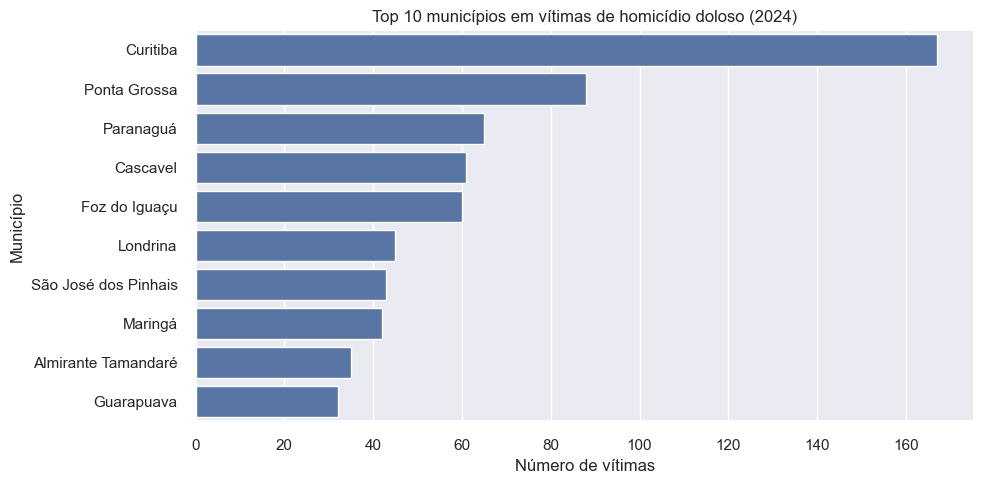

In [64]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=homi_2024,
    x="quantidade",
    y="municipio",
    orient="h"
)
plt.title("Top 10 municípios em vítimas de homicídio doloso (2024)")
plt.xlabel("Número de vítimas")
plt.ylabel("Município")
plt.tight_layout()
plt.show()


**Interpretação:** observa-se a concentração de vítimas de homicídio doloso
em grandes centros urbanos e polos regionais, como a capital e cidades de
porte médio. Em termos absolutos, isso é compatível com a maior população
desses municípios. Para avaliar o risco relativo, seria necessário calcular
taxas por 100 mil habitantes, o que foge ao escopo deste estudo.


## 11. Evolução dos crimes contra o patrimônio (Estado do Paraná)

Dada a relevância dos crimes patrimoniais no volume total de ocorrências,
analisamos sua evolução específica ao longo do período.


In [65]:
patrimonio = estado.query("grupo_crime == 'Crimes contra o patrimônio'")

patrimonio_ano = (
    patrimonio.groupby("ano")["quantidade"]
    .sum()
    .reset_index()
)

patrimonio_ano


,ano,quantidade
0,2018,287548
1,2019,267365
2,2020,261052
3,2021,317274
4,2022,362977
5,2023,352376
6,2024,339920


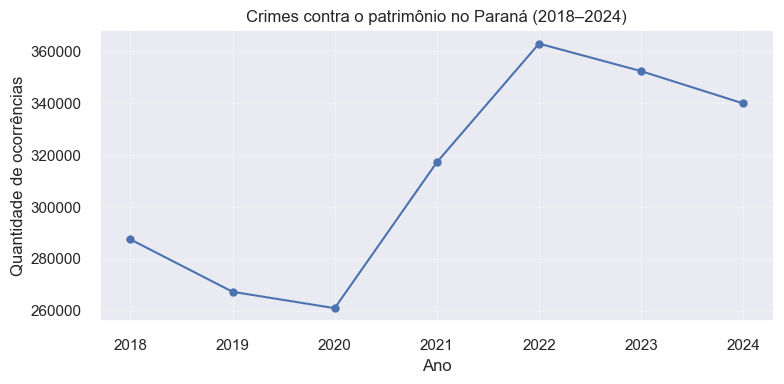

In [66]:
plt.figure(figsize=(8, 4))
plt.plot(patrimonio_ano["ano"], patrimonio_ano["quantidade"], marker="o")
plt.title("Crimes contra o patrimônio no Paraná (2018–2024)")
plt.xlabel("Ano")
plt.ylabel("Quantidade de ocorrências")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretação:** os crimes contra o patrimônio apresentam uma trajetória de
queda entre 2018 e 2020, seguida por forte aumento a partir de 2021, com pico
em 2022. Ainda que haja uma redução moderada em 2023 e 2024, o patamar recente
permanece superior ao observado no início da série, sugerindo uma pressão
contínua desse tipo de ocorrência sobre o sistema de segurança pública.


## 12. Mortes violentas intencionais (MVI)

Nesta seção, aprofundamos a análise sobre as mortes violentas intencionais,
avaliando sua evolução ao longo do tempo, sua participação no total de ocorrências
e a distribuição entre tipos de morte violenta após 2020.


In [67]:
# Filtra apenas mortes violentas intencionais para o Estado do PR
mvi_estado = estado.query("grupo_crime == 'Mortes violentas intencionais'").copy()

mvi_estado_ano = (
    mvi_estado.groupby("ano")["quantidade"]
    .sum()
    .reset_index()
)

mvi_estado_ano


,ano,quantidade
0,2018,2172
1,2019,2043
2,2020,2204
3,2021,2105
4,2022,2208
5,2023,2037
6,2024,1781


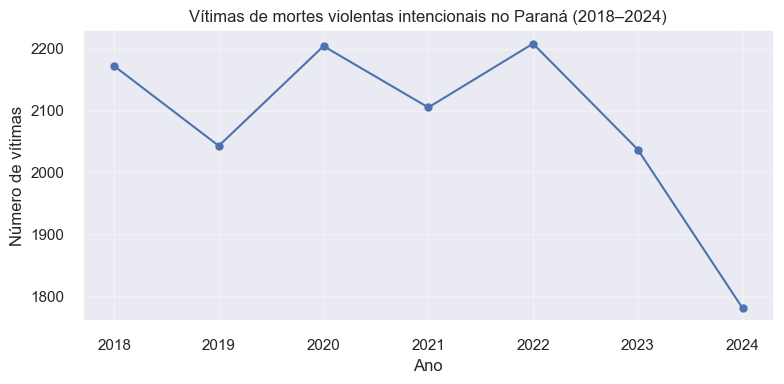

In [68]:
plt.figure(figsize=(8, 4))
plt.plot(mvi_estado_ano["ano"], mvi_estado_ano["quantidade"], marker="o")
plt.title("Vítimas de mortes violentas intencionais no Paraná (2018–2024)")
plt.xlabel("Ano")
plt.ylabel("Número de vítimas")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [69]:
tot_ano = (
    estado.groupby("ano")["quantidade"]
    .sum()
    .rename("total_ano")
    .reset_index()
)

mvi_pct = mvi_estado_ano.merge(tot_ano, on="ano")
mvi_pct["perc"] = mvi_pct["quantidade"] / mvi_pct["total_ano"] * 100

mvi_pct


,ano,quantidade,total_ano,perc
0,2018,2172,535047,0.405946
1,2019,2043,525214,0.388984
2,2020,2204,492477,0.447534
3,2021,2105,544375,0.386682
4,2022,2208,587626,0.375749
5,2023,2037,616806,0.330250
6,2024,1781,613797,0.290161


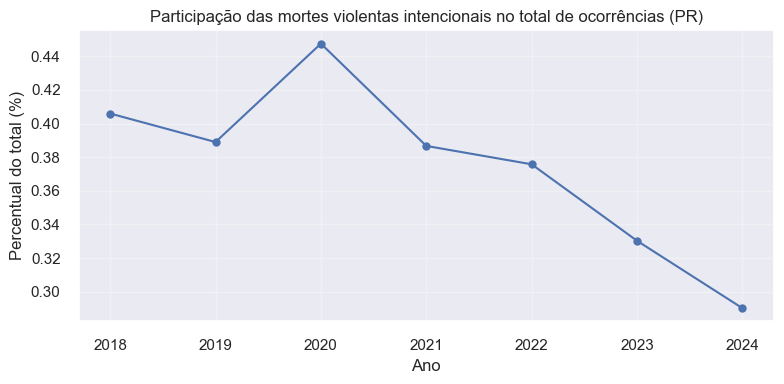

In [70]:
plt.figure(figsize=(8, 4))
plt.plot(mvi_pct["ano"], mvi_pct["perc"], marker="o")
plt.title("Participação das mortes violentas intencionais no total de ocorrências (PR)")
plt.xlabel("Ano")
plt.ylabel("Percentual do total (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretação:** o número de mortes violentas intencionais oscila ao longo da
série, mas representa uma parcela muito pequena do total de ocorrências
registradas. Isso reforça a ideia de que, embora numericamente pouco frequentes,
essas ocorrências possuem grande impacto social e demandam políticas específicas.


In [71]:
mvi_tipo_ano = (
    estado.query("grupo_crime == 'Mortes violentas intencionais' and ano >= 2020")
    .groupby(["ano", "tipo_crime"])["quantidade"]
    .sum()
    .reset_index()
)

mvi_tipo_ano


,ano,tipo_crime,quantidade
0,2020,Vítimas de Feminicídio,73
1,2020,Vítimas de Homicídio Doloso,2008
2,2020,Vítimas de Homicídio Doloso no Trânsito,18
3,2020,Vítimas de Lesão Corporal com Resultado de Morte,45
4,2020,Vítimas de Roubo com Resultado de Morte (Latro...,60
5,2021,Vítimas de Feminicídio,75
6,2021,Vítimas de Homicídio Doloso,1913
7,2021,Vítimas de Homicídio Doloso no Trânsito,37
8,2021,Vítimas de Lesão Corporal com Resultado de Morte,39
9,2021,Vítimas de Roubo com Resultado de Morte (Latro...,41


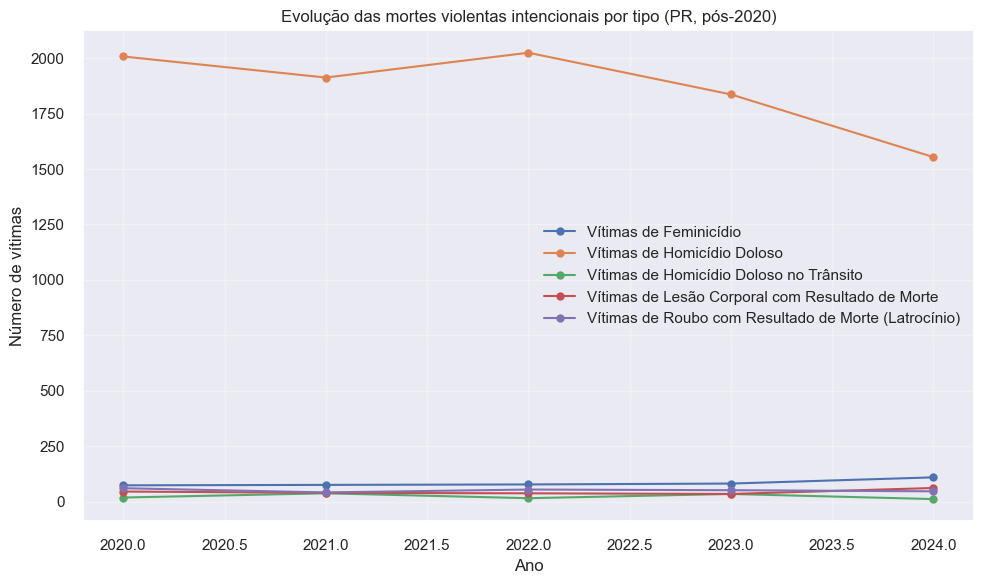

In [72]:
plt.figure(figsize=(10, 6))
for tipo in mvi_tipo_ano["tipo_crime"].unique():
    dados = mvi_tipo_ano[mvi_tipo_ano["tipo_crime"] == tipo]
    plt.plot(dados["ano"], dados["quantidade"], marker="o", label=tipo)

plt.title("Evolução das mortes violentas intencionais por tipo (PR, pós-2020)")
plt.xlabel("Ano")
plt.ylabel("Número de vítimas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretação:** a decomposição por tipo mostra quais modalidades de morte
violenta contribuem mais para o total, como homicídio doloso, feminicídio,
latrocínio ou homicídios no trânsito. As variações entre os anos ajudam a
identificar possíveis mudanças no padrão dessas ocorrências específicas.


In [73]:
mvi_mun_2024 = (
    municipios.query("grupo_crime == 'Mortes violentas intencionais' and ano == 2024")
    .groupby("municipio")["quantidade"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

mvi_mun_2024


,municipio,quantidade
0,Curitiba,191
1,Ponta Grossa,103
2,Paranaguá,68
3,Foz do Iguaçu,67
4,Cascavel,64
5,Londrina,53
6,Maringá,47
7,São José dos Pinhais,44
8,Almirante Tamandaré,37
9,Guarapuava,37


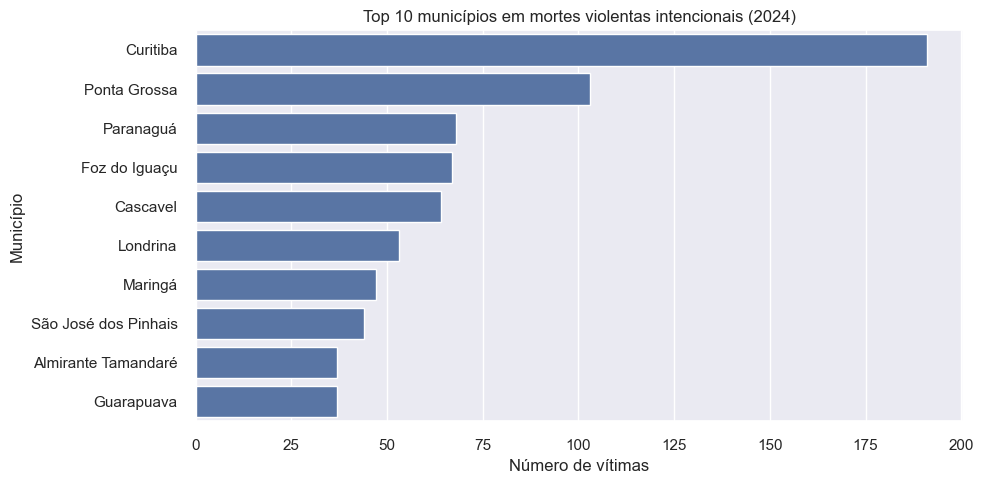

In [74]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=mvi_mun_2024,
    x="quantidade",
    y="municipio",
    orient="h"
)
plt.title("Top 10 municípios em mortes violentas intencionais (2024)")
plt.xlabel("Número de vítimas")
plt.ylabel("Município")
plt.tight_layout()
plt.show()


**Interpretação:** assim como observado para o homicídio doloso, as mortes
violentas intencionais concentram-se em municípios maiores e em polos regionais.
Novamente, trata-se de uma análise em números absolutos, que não leva em conta
o tamanho da população de cada localidade.


## 13. Crimes de estelionato no período pós-2020

Nesta seção, aprofundamos a análise dos crimes de estelionato, que apresentam
forte relação com golpes financeiros e fraudes, incluindo golpes virtuais.
O foco é avaliar a evolução após 2020 e a concentração por município.


In [75]:
estel_estado = estado.query("tipo_crime == 'Crimes de Estelionato'").copy()

estel_estado_ano = (
    estel_estado.groupby("ano")["quantidade"]
    .sum()
    .reset_index()
)

estel_estado_ano


,ano,quantidade
0,2018,29856
1,2019,40701
2,2020,70543
3,2021,117450
4,2022,142183
5,2023,147993
6,2024,160637


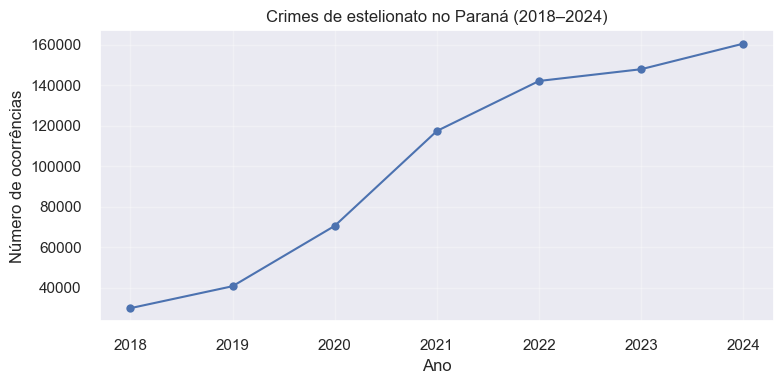

In [76]:
plt.figure(figsize=(8, 4))
plt.plot(estel_estado_ano["ano"], estel_estado_ano["quantidade"], marker="o")
plt.title("Crimes de estelionato no Paraná (2018–2024)")
plt.xlabel("Ano")
plt.ylabel("Número de ocorrências")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [77]:
estel_pct = estel_estado_ano.merge(tot_ano, on="ano")
estel_pct["perc"] = estel_pct["quantidade"] / estel_pct["total_ano"] * 100

estel_pct


,ano,quantidade,total_ano,perc
0,2018,29856,535047,5.580071
1,2019,40701,525214,7.749413
2,2020,70543,492477,14.324121
3,2021,117450,544375,21.575201
4,2022,142183,587626,24.196172
5,2023,147993,616806,23.993444
6,2024,160637,613797,26.171030


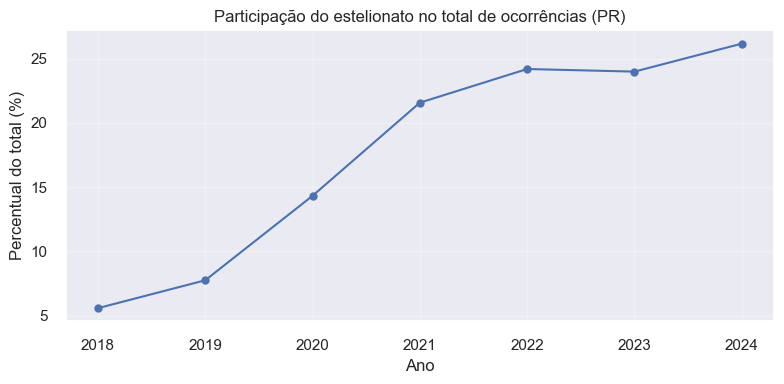

In [78]:
plt.figure(figsize=(8, 4))
plt.plot(estel_pct["ano"], estel_pct["perc"], marker="o")
plt.title("Participação do estelionato no total de ocorrências (PR)")
plt.xlabel("Ano")
plt.ylabel("Percentual do total (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretação:** a evolução dos crimes de estelionato ao longo da série
indica em que medida esse tipo de ocorrência ganhou espaço dentro do conjunto
total de registros. A partir de 2020, é possível relacionar parte desse
comportamento à intensificação de transações digitais e ao aumento de golpes
financeiros, ainda que essa conexão não possa ser comprovada apenas com os dados
utilizados neste trabalho.


In [79]:
estel_mun_2024 = (
    municipios.query("ano == 2024 and tipo_crime == 'Crimes de Estelionato'")
    .sort_values("quantidade", ascending=False)
    .head(10)
)

estel_mun_2024


,municipio,regiao,ano,tipo_crime,quantidade,fonte,grupo_crime
7498,Curitiba,RGI de Curitiba,2024,Crimes de Estelionato,41168,Crimes gerais,Crimes contra o patrimônio
15043,Londrina,RGI de Londrina,2024,Crimes de Estelionato,9591,Crimes gerais,Crimes contra o patrimônio
16496,Maringá,RGI de Maringá,2024,Crimes de Estelionato,7760,Crimes gerais,Crimes contra o patrimônio
21635,Ponta Grossa,RGI de Ponta Grossa,2024,Crimes de Estelionato,6586,Crimes gerais,Crimes contra o patrimônio
5485,Cascavel,RGI de Cascavel,2024,Crimes de Estelionato,5851,Crimes gerais,Crimes contra o patrimônio
27445,São José dos Pinhais,RGI de Curitiba,2024,Crimes de Estelionato,5778,Crimes gerais,Crimes contra o patrimônio
9446,Foz do Iguaçu,RGI de Foz do Iguaçu,2024,Crimes de Estelionato,4668,Crimes gerais,Crimes contra o patrimônio
6312,Colombo,RGI de Curitiba,2024,Crimes de Estelionato,3347,Crimes gerais,Crimes contra o patrimônio
20847,Pinhais,RGI de Curitiba,2024,Crimes de Estelionato,2598,Crimes gerais,Crimes contra o patrimônio
10670,Guarapuava,RGI de Guarapuava,2024,Crimes de Estelionato,2464,Crimes gerais,Crimes contra o patrimônio


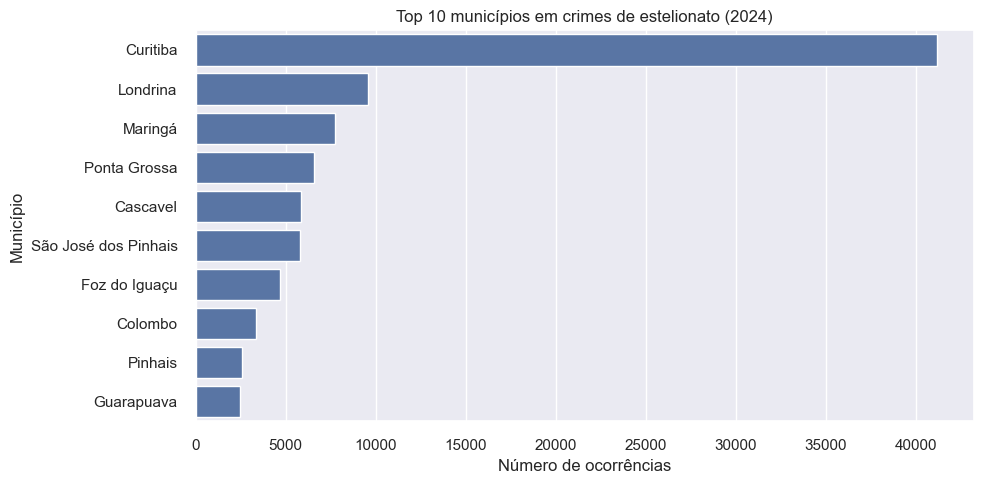

In [80]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=estel_mun_2024,
    x="quantidade",
    y="municipio",
    orient="h"
)
plt.title("Top 10 municípios em crimes de estelionato (2024)")
plt.xlabel("Número de ocorrências")
plt.ylabel("Município")
plt.tight_layout()
plt.show()


In [81]:
estel_mun_2018 = (
    municipios.query("ano == 2018 and tipo_crime == 'Crimes de Estelionato'")
    .sort_values("quantidade", ascending=False)
    .head(10)
)

estel_mun_2018


,municipio,regiao,ano,tipo_crime,quantidade,fonte,grupo_crime
7492,Curitiba,RGI de Curitiba,2018,Crimes de Estelionato,8716,Crimes gerais,Crimes contra o patrimônio
15037,Londrina,RGI de Londrina,2018,Crimes de Estelionato,2024,Crimes gerais,Crimes contra o patrimônio
16490,Maringá,RGI de Maringá,2018,Crimes de Estelionato,1566,Crimes gerais,Crimes contra o patrimônio
5479,Cascavel,RGI de Cascavel,2018,Crimes de Estelionato,1287,Crimes gerais,Crimes contra o patrimônio
21629,Ponta Grossa,RGI de Ponta Grossa,2018,Crimes de Estelionato,1021,Crimes gerais,Crimes contra o patrimônio
27439,São José dos Pinhais,RGI de Curitiba,2018,Crimes de Estelionato,984,Crimes gerais,Crimes contra o patrimônio
9440,Foz do Iguaçu,RGI de Foz do Iguaçu,2018,Crimes de Estelionato,764,Crimes gerais,Crimes contra o patrimônio
6306,Colombo,RGI de Curitiba,2018,Crimes de Estelionato,539,Crimes gerais,Crimes contra o patrimônio
4104,Cambé,RGI de Londrina,2018,Crimes de Estelionato,445,Crimes gerais,Crimes contra o patrimônio
20841,Pinhais,RGI de Curitiba,2018,Crimes de Estelionato,423,Crimes gerais,Crimes contra o patrimônio


In [82]:
estel_mun = (
    municipios
    .query("tipo_crime == 'Crimes de Estelionato' and ano >= 2020")
    .groupby(["municipio", "ano"])["quantidade"]
    .sum()
    .reset_index()
)

estel_pivot = estel_mun.pivot(index="municipio", columns="ano", values="quantidade")

# considera 0 onde não havia registro
estel_pivot = estel_pivot.fillna(0)

# cria colunas de variação absoluta e percentual 2020–2024
if 2020 in estel_pivot.columns and 2024 in estel_pivot.columns:
    estel_pivot["var_abs_2020_2024"] = estel_pivot[2024] - estel_pivot[2020]
    estel_pivot["var_pct_2020_2024"] = (
        (estel_pivot[2024] - estel_pivot[2020]) / estel_pivot[2020].replace(0, pd.NA)
    ) * 100

estel_pivot.head()


ano,2020,2021,2022,2023,2024,var_abs_2020_2024,var_pct_2020_2024
municipio,,,,,,,
Abatiá,23,34,51,43,71,48,208.695652
Adrianópolis,24,53,32,34,26,2,8.333333
Agudos do Sul,27,45,76,85,102,75,277.777778
Almirante Tamandaré,421,915,1127,1270,1395,974,231.353919
Altamira do Paraná,12,25,21,11,19,7,58.333333


In [83]:
top_var_abs = (
    estel_pivot.sort_values("var_abs_2020_2024", ascending=False)
    .head(10)[["var_abs_2020_2024"]]
    .reset_index()
)

top_var_abs


ano,municipio,var_abs_2020_2024
0,Curitiba,22171
1,Londrina,4427
2,Ponta Grossa,4020
3,Maringá,3832
4,Cascavel,3756
5,São José dos Pinhais,3583
6,Foz do Iguaçu,2739
7,Colombo,2059
8,Toledo,1955
9,Guarapuava,1636


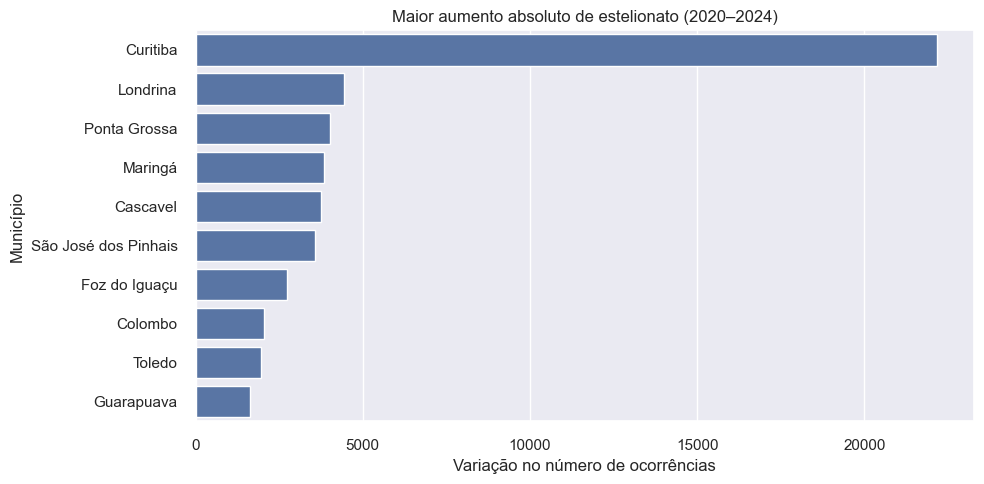

In [84]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_var_abs,
    x="var_abs_2020_2024",
    y="municipio",
    orient="h"
)
plt.title("Maior aumento absoluto de estelionato (2020–2024)")
plt.xlabel("Variação no número de ocorrências")
plt.ylabel("Município")
plt.tight_layout()
plt.show()


**Interpretação:** a análise por município permite identificar locais em que
o estelionato cresceu de forma mais intensa entre 2020 e 2024. Esse aumento
pode estar associado a fatores locais, como estrutura econômica, nível de
digitalização das transações e ações de repressão ou de registro.
